# load code

In [1]:
include("src/PLIntegration1D.jl");
using .PLIntegration1D

In [2]:
include("src/ContourIntersection.jl");
using .ContourIntersection

In [ ]:
include("src/critical-points.jl")

In [ ]:
include("src/saddle-point-method.jl")

In [6]:
using CairoMakie

# setup

(This is what you need to adjust according to your definitions of the fields, the momentum, target etc.)

In [4]:
include("AnnesATI.jl")

## fixed parameters

In [6]:
const λ = 800 # nm
const Intensity0 = 4e14 # W/cm2
const Ip = IpAU(15.7596) # Argon gas target

const ω = 2 * π * LAU * c / λ
const TC = 2*π/ω;

## field configurations

In [7]:
beam1 = let
    beam = BeamMono(Intensity = Intensity0, 
    lambda=λ, epsilon=0.,
    phi = 0.)
end

BeamMono(0.10690449676496976, 0.056939529014612654, 0.0, 0.0)

In [9]:
beam2 = let # co-linear two-colour field with mixing angle θ, "tunnelling without barrier"-scenario
    θ = 0.#π/4
    beam = BeamBETC(Intensity1 = (cos(θ))^2 * Intensity0, 
    Intensity2 = (sin(θ))^2 * Intensity0,
    lambda=λ, r=1,s=2, epsilon=0.,
    phi = +π/2)
end

BeamTC(0.10690449676496976, 0.0, 0.056939529014612654, 0.11387905802922531, 0.0, 0.0, 1.5707963267948966)

In [10]:
beam3 = let # fully 2ω field
    θ = π/2
    beam = BeamBETC(Intensity1 = (cos(θ))^2 * Intensity0, 
    Intensity2 = (sin(θ))^2 * Intensity0,
    lambda=λ,r=1,s=2,epsilon=0.,
    phi = 0.)
end

BeamTC(6.546012488883939e-18, 0.10690449676496976, 0.056939529014612654, 0.11387905802922531, 0.0, 0.0, 0.0)

In [66]:
beam4 = let # just a random other weird field
    θ = 0.3 #π/6
    beam = BeamBETC(Intensity1 = (cos(θ))^2 * Intensity0, 
    Intensity2 = (sin(θ))^2 * Intensity0,
    lambda=λ,r=1,s=2,epsilon=0.,
    phi = +π/3)
end

BeamTC(0.1021297666111859, 0.03159243897701037, 0.056939529014612654, 0.11387905802922531, 0.0, 0.0, 1.0471975511965976)

### plot the field shape over time

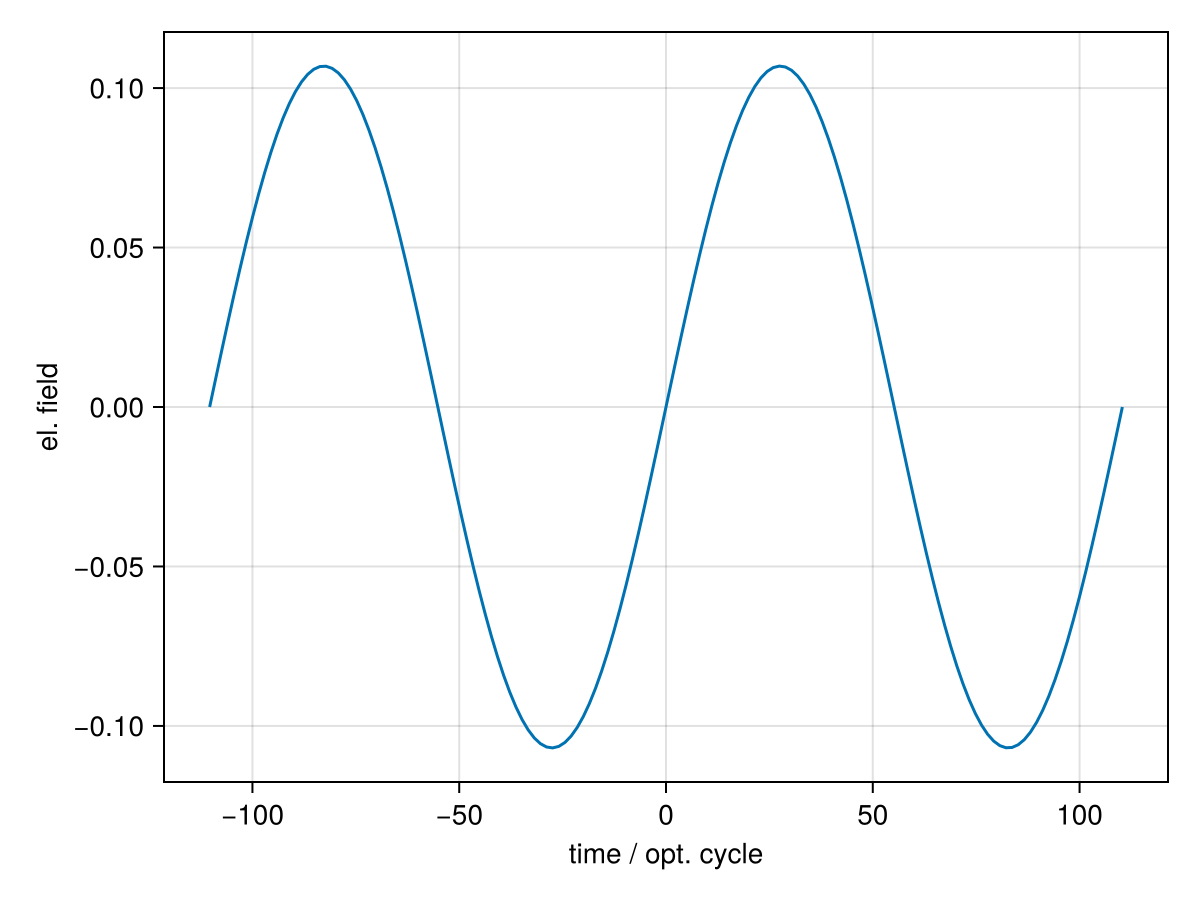

In [9]:
let
    beam = beam1

    Nt = 150
    times = range(-TC, stop = TC, length = Nt)    
    
    efield = [E(beam)(t)[1] for t in times] # only the [1] component (x)

    f = Figure()
    ax = Axis(f[1, 1],
        xlabel = "time / opt. cycle",
        ylabel = "el. field",
    ) 
    
    lines!(ax, times, efield)

    f
end

## momentum grid

In [ ]:
momx = range(-2, stop = 2., step = 0.05)
momy = momx;

## transition amplitude

In [ ]:
### this is just a dummy placeholder, you'll have to redefine this however you want and however it suits your setup
function transition_amplitude(time_int::ComplexF64, momentum::Vector, Ip::Float64)
    ### time_int is the time-dependent integral (including time-dependent prefactors) which we will evaluate however
    return sqrt(1/(4*π)) * Ip * sqrt(sum(momentum.^2)) * time_int
end

# integrate the flowed integration domain

## get thimble first, and then integrate

In [10]:
let
    #####
    beam = beam1
    momentum = [0.,0.] # wants to be a Vector
    Nsteps = 20
    flowfactor = 1.
    
    #########
    
    
    ### define your phase functions, as functions of 't' only
    S(t) = action(beam, momentum, t)
    S_drv(t) = action_drv(beam, momentum, t)
    
    tmin = 0. + 0im # min(t real) + 0.
    tmax = TC + TC/2*im # min(t real) + max(t imag)
    
    points, simplices = get_thimble(S, S_drv, real(tmin), real(tmax),
        Nflow = Nsteps, flowstepfactor = flowfactor, h_threshold=-500.)
    
    integrate_thimble(S, points, simplices)
end

-0.11925538651167494 + 0.236767136942736im

## integrate the flowed domain directly (faster)

In [10]:
let
    #####
    beam = beam1
    momentum = [0.,0.] # wants to be a Vector  
    #########
    
    
    ### define your phase functions, as functions of 't' only
    S(t) = action(beam, momentum, t)
    S_drv(t) = action_drv(beam, momentum, t)
    
    tmin = 0. + 0im # min(t real) + 0.
    tmax = TC + TC/2*im # min(t real) + max(t imag)
    
    ### return the integral, the points and the simplices
    integrate_thimble(S, S_drv, tmin, tmax, print_message=false)
end

(-0.11925554780679952 + 0.23676745717468542im, Main.PLIntegration1D.Point[Main.PLIntegration1D.Point(0.0 + 6.0im, true), Main.PLIntegration1D.Point(110.34838917559546 + 6.0im, true), Main.PLIntegration1D.Point(55.17419458779773 + 6.0im, true), Main.PLIntegration1D.Point(27.587097293898864 + 3.398699565166527im, true), Main.PLIntegration1D.Point(82.7612918816966 + 3.398699565166527im, true), Main.PLIntegration1D.Point(12.984799753207776 + 5.90841486308116im, true), Main.PLIntegration1D.Point(42.189394834589955 + 5.90841486308116im, true), Main.PLIntegration1D.Point(68.15899434100551 + 5.908414863081159im, true), Main.PLIntegration1D.Point(97.36358942238768 + 5.908414863081159im, true), Main.PLIntegration1D.Point(6.4956352598531435 + 5.9777205050668005im, true)  …  Main.PLIntegration1D.Point(45.43548121770748 + 5.94886128413205im, true), Main.PLIntegration1D.Point(51.92498285244158 + 5.994519852195295im, true), Main.PLIntegration1D.Point(58.42340632315388 + 5.994519852195295im, true), Ma

## show how the integral converges over the number of flow steps

I stopped because I reached the maximum flow steps, i.e. 1, with 32 simplices.
I stopped because I reached the maximum flow steps, i.e. 2, with 32 simplices.
abs(integrals[end]) = 0.26510510078017424


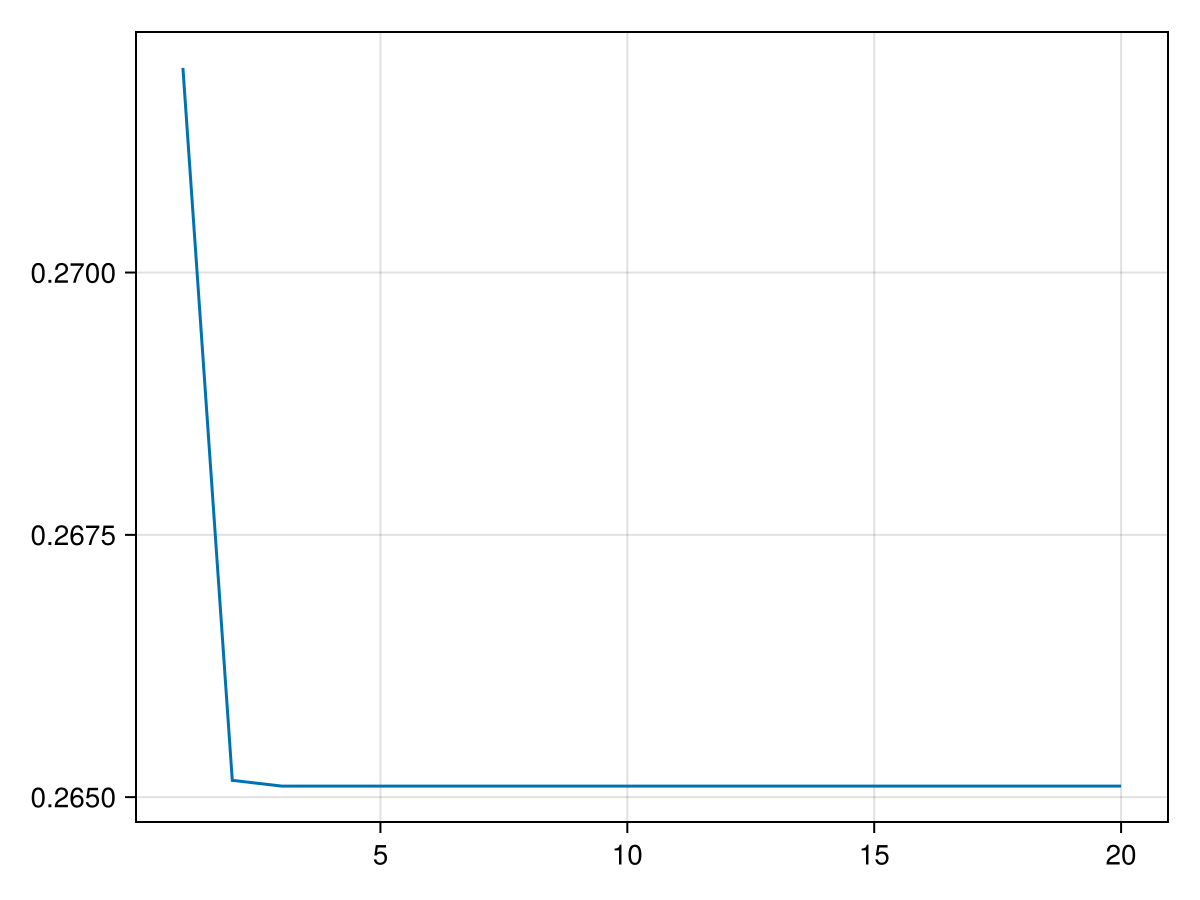

In [36]:
let
    #####
    beam = beam1
    momentum = [0.,0.] # wants to be a Vector    
    #########
    
    
    ### define your phase functions, as functions of 't' only
    S(t) = action(beam, momentum, t)
    S_drv(t) = action_drv(beam, momentum, t)
    
    tmin = 0. + 0im # min(t real) + 0.
    tmax = TC + TC/2*im # min(t real) + max(t imag)
    
    integrals = Vector()
    for N in 1:20
        int, _,_ = integrate_thimble(S, S_drv, tmin, tmax, print_message=false, Nmax=N)
        push!(integrals, int)
    end
    @show abs(integrals[end])
    f = lines(1:20, abs.(integrals))
#     ylims!(0.265, 0.266)
#     f
    
end

## calculate some transition amplitude for full momentum space

In [68]:
pemd_flow = let
    #####
    beam = beam4
    #########
    
    ### define your phase functions, as functions of 't' only
    tmin = 0. + 0im # min(t real) + 0.
    tmax = TC + TC/2*im # min(t real) + max(t imag)
    
    pemd = Array{ComplexF64}(undef, length(momy), length(momx));

    Threads.@threads for j in eachindex(momy)
        for k in eachindex(momx)
            momentum = [momx[k], momy[j]]
            
            ### define your own phase functions here, as functions of t
            S(t) = action(beam, momentum, t)
            S_drv(t) = action_drv(beam, momentum, t)
            
            ### if you have a prefactor that depends on t, you can specify it as a function, see below
            int, _,_ = integrate_thimble(S, S_drv, tmin, tmax, print_message=false, prefactor = t -> 2*t)
            
            ### however you want to calculate your transition amplitude goes here
#             ampl = sqrt(1/(4*π)) * int
            pemd[j, k] = transition_amplitude(int, momentum, Ip)
        end
    end
    
    pemd
end;

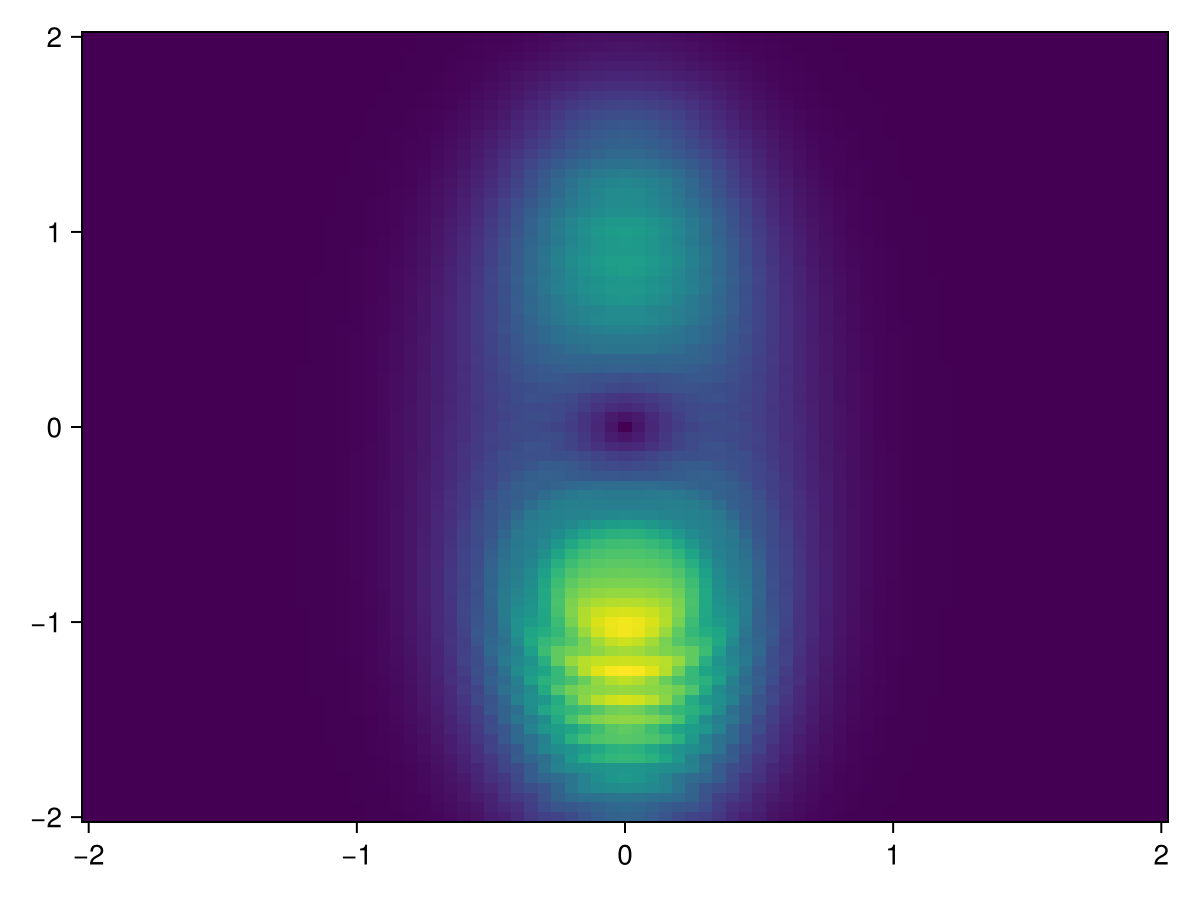

In [71]:
heatmap(momx, momy, abs.(pemd_flow))

# integrating using saddle-point method

## finding saddle points and telling whether they are relevant

In [18]:
let
    beam = beam1  
    momentum = [0.,0.] # wants to be a Vector
    
    ### define your phase functions, as functions of 't' only
    S(t) = action(beam, momentum, t)
    S_drv(t) = action_drv(beam, momentum, t)

    ### get saddle points
    tmin = 0. + 0im # min(t real) + 0.
    tmax = TC + TC/2*im # min(t real) + max(t imag)
    
    saddles = filter(ts -> real(tmin) < real(ts) < real(tmax), 
        filter(ts->imag(ts)>0, find_saddles_sobol(S_drv, tmin, tmax, 300))
        )
#     display(saddles)
    
    for ts in saddles
        @show ts
        relevant = is_contributing(ts, S, tmin, tmax)
        @show relevant
    end
    
end  

ts = 27.59 + 9.58im
relevant = true
ts = 82.76 + 9.58im
relevant = true


## calculate saddle-point integral 

In [41]:
### for one saddle point
let
    beam = beam1  
    momentum = [0.,0.] # wants to be a Vector
    
    ### define your phase functions, as functions of 't' only
    S(t) = action(beam, momentum, t)
    S_drv(t) = action_drv(beam, momentum, t)
    S_drv2(t) = action_2drv(beam, momentum, t)

    ### get saddle points
    tmin = 0. + 0im # min(t real) + 0.
    tmax = 0.5*TC + TC/2*im # min(t real) + max(t imag)
    
    int_flow, _, _ = integrate_thimble(S, S_drv, tmin, tmax, print_message=false)
    @show int_flow
    
    saddles = filter(ts -> real(tmin) < real(ts) < real(tmax), 
        filter(ts->imag(ts)>0, find_saddles_sobol(S_drv, tmin, tmax, 300))
        )
#     display(saddles)
    
    for ts in saddles
        @show ts
        relevant = is_contributing(ts, S, tmin, tmax)
        @show relevant
        
        if relevant
            int = integrate_around_saddle_point(ts, S, S_drv, S_drv2)  
            @show int
        end
    end

end  

int_flow = -0.13255255039008637 + 0.08165281855272527im
ts = 27.59 + 9.58im
relevant = true
int = -0.13501286874548746 + 0.08312945493884268im


In [43]:
### combining whole region
let
    beam = beam1  
    momentum = [0.,0.] # wants to be a Vector
    
    ### define your phase functions, as functions of 't' only
    S(t) = action(beam, momentum, t)
    S_drv(t) = action_drv(beam, momentum, t)
    S_drv2(t) = action_2drv(beam, momentum, t)

    ### get saddle points
    tmin = 0. + 0im # min(t real) + 0.
    tmax = TC + TC/2*im # min(t real) + max(t imag)
    
    int_flow, _, _ = integrate_thimble(S, S_drv, tmin, tmax, print_message=false)
    @show int_flow
    
    saddles = filter(ts -> real(tmin) < real(ts) < real(tmax), 
        filter(ts->imag(ts)>0, find_saddles_sobol(S_drv, tmin, tmax, 300))
        )
#     display(saddles)
    int_SPM = complex(0.)
    for ts in saddles
        @show ts
        relevant = is_contributing(ts, S, tmin, tmax)
        @show relevant
        
        if relevant
            int_SPM += integrate_around_saddle_point(ts, S, S_drv, S_drv2)  
#             @show int
        end
    end
    @show int_SPM

end; 

int_flow = -0.11925554780679952 + 0.23676745717468542im
ts = 27.59 + 9.58im
relevant = true
ts = 82.76 + 9.58im
relevant = true
int_SPM = -0.1214560994933101 + 0.24110166184925624im


## calculate whole PEMD with SPM

In [69]:
pemd_SPM = let
    #####
    beam = beam4
    #########
    
    ### define your phase functions, as functions of 't' only
    tmin = 0. + 0im # min(t real) + 0.
    tmax = TC + TC/2*im # min(t real) + max(t imag)
    
    pemd = Array{ComplexF64}(undef, length(momy), length(momx));

    Threads.@threads for j in eachindex(momy)
        for k in eachindex(momx)
            momentum = [momx[k], momy[j]]
            
            ### define your own phase functions here, as functions of t
            S(t) = action(beam, momentum, t)
            S_drv(t) = action_drv(beam, momentum, t)
            S_drv2(t) = action_2drv(beam, momentum, t)

            ## if you have a prefactor that depends on t, you can specify it as a function, see below
            int = integrate_SPM(S, S_drv, S_drv2, tmin, tmax, prefactor = t -> 2*t)
            
#             ### however you want to calculate your transition amplitude goes here
            pemd[j, k] = transition_amplitude(int, momentum, Ip)
        end
    end
    
    pemd
end;

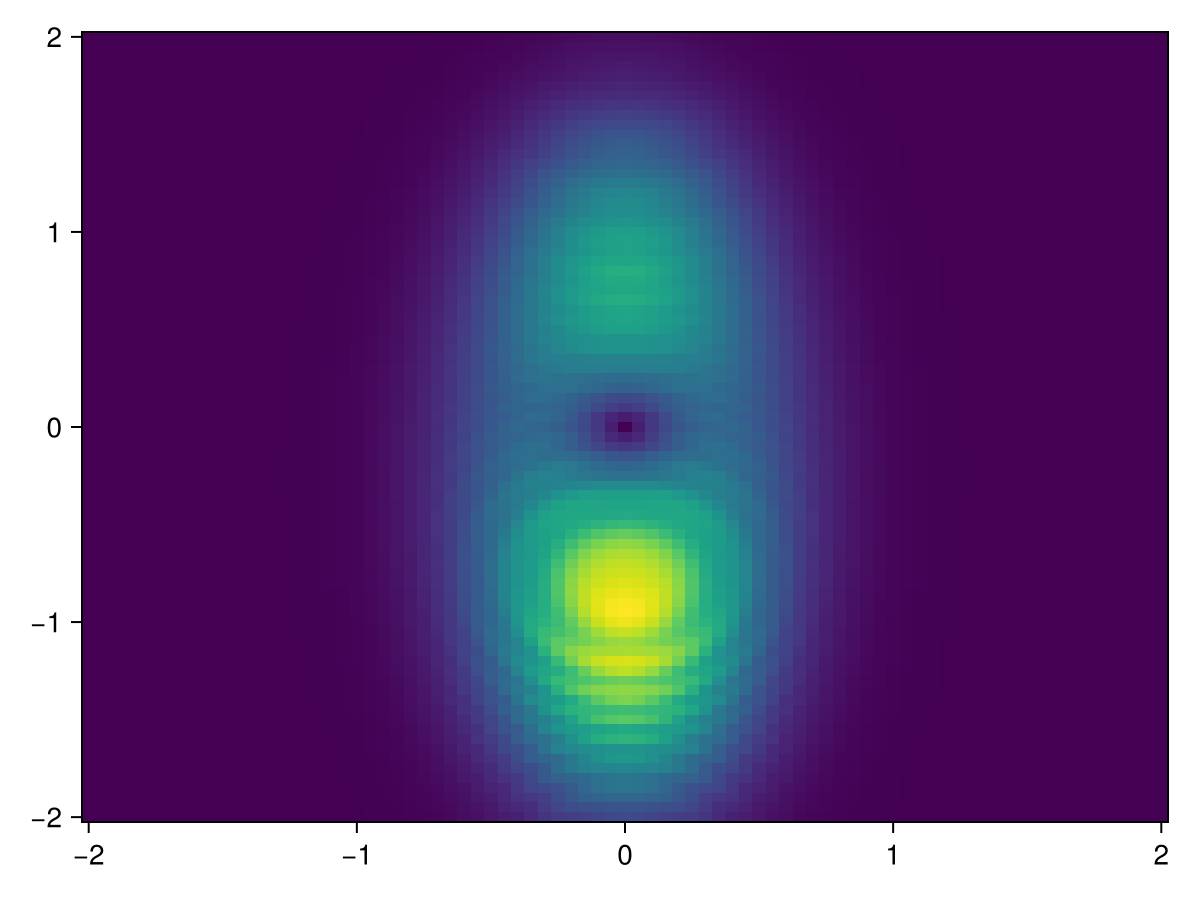

In [70]:
heatmap(momx, momy, abs.(pemd_SPM))